# 📡 ISCX VPN/Non-VPN 트래픽 유형 분류 (다중 클래스)
본 노트북에서는 ISCX VPN/Non-VPN 데이터셋으로부터 `.pcap` 파일을 처리하여, 트래픽 유형(chat, email, audio 등)을 분류하는 머신러닝 모델을 구성합니다.

## 📁 1. 환경 설정 및 필요 라이브러리 불러오기

In [13]:

# 파일 처리, 머신러닝, 시각화를 위한 라이브러리들을 불러옵니다.
import os
import pandas as pd
import subprocess
import glob
from tqdm import tqdm

# sklearn은 머신러닝 모델 학습과 평가에 사용됩니다.
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# 시각화를 위한 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns


## 📂 2. 데이터셋 경로 및 출력 경로 설정

In [14]:

# Non-VPN 및 VPN 데이터셋이 저장된 디렉토리 경로를 지정합니다.
NONVPN_DIR = "dataset/NonVPN-PCAPs-01"
VPN_DIR = "dataset/VPN-PCAPS-01"

# 추출된 CSV 파일들을 저장할 출력 디렉토리입니다.
OUTPUT_DIR = "dataset/output_csvs"
os.makedirs(OUTPUT_DIR, exist_ok=True)  # 디렉토리가 없으면 생성


## 🏷️ 3. 트래픽 유형(label) 분류 함수

In [15]:

# 파일 이름에 포함된 키워드를 바탕으로 트래픽 유형을 분류합니다.
def get_traffic_type(filename):
    fname = filename.lower()
    if 'chat' in fname:
        return 'chat'
    elif 'email' in fname:
        return 'email'
    elif 'audio' in fname:
        return 'audio'
    elif 'video' in fname:
        return 'video'
    elif 'ftp' in fname or 'file' in fname or 'bittorrent' in fname:
        return 'file_transfer'
    else:
        return 'other'  # 위의 조건에 포함되지 않으면 기타로 분류


## 🧪 4. PCAP 파일 → CSV 피처 추출 함수

In [16]:

# tshark를 사용하여 pcap 파일로부터 주요 통계 피처를 추출한 후, CSV로 저장합니다.
def extract_and_save_csv(pcap_path, output_csv_path, label):
    tshark_fields = [
        "-T", "fields",
        "-e", "frame.time_relative",  # 패킷의 상대 시간
        "-e", "frame.len",            # 패킷 길이
        "-e", "ip.src",               # 출발지 IP
        "-e", "ip.dst",               # 목적지 IP
        "-E", "separator=,"
    ]
    cmd = ["tshark", "-r", pcap_path] + tshark_fields

    try:
        output = subprocess.check_output(cmd, stderr=subprocess.DEVNULL).decode()
        lines = output.strip().split("\n")
        packets = [line.split(",") for line in lines if len(line.split(",")) == 4]
        df = pd.DataFrame(packets, columns=["time", "length", "src", "dst"])
        df["time"] = pd.to_numeric(df["time"], errors='coerce')
        df["length"] = pd.to_numeric(df["length"], errors='coerce')
        df = df.dropna()

        # 흐름 단위 정의 (src-IP와 dst-IP 조합)
        df["flow"] = df["src"] + "-" + df["dst"]

        # 흐름 기준으로 통계 피처 집계
        features = df.groupby("flow").agg({
            "time": ["min", "max"],
            "length": ["count", "sum", "mean", "std"]
        }).reset_index()

        # 컬럼 이름 정리
        features.columns = ["flow", "time_min", "time_max", "packet_count", "total_bytes", "avg_pkt_size", "std_pkt_size"]
        features["duration"] = features["time_max"] - features["time_min"]  # 흐름 지속 시간 계산
        features = features.drop(columns=["time_min", "time_max"])  # 불필요한 컬럼 제거
        features["label"] = label  # 클래스 레이블 추가

        # 결과를 CSV로 저장
        if not features.empty:
            features.to_csv(output_csv_path, index=False)
    except Exception as e:
        print(f"[⚠️] Error processing {pcap_path}: {e}")


## 🔁 5. 전체 PCAP 파일 처리 및 CSV 저장

In [17]:
# 전체 pcap 파일들을 순회하며 피처를 추출하고 CSV 파일로 저장합니다.
# (이미 output_multiple.csv가 존재하면 시간 소요가 큰 재추출을 안전하게 건너뜁니다)
import os, glob, subprocess
from tqdm import tqdm

def batch_convert_pcaps():
    if os.path.exists('output_multiple.csv') or os.path.exists('code/output_multiple.csv'):
        print('💡 안내: 이미 전처리된 output_multiple.csv가 존재하므로 PCAP 원본 재추출을 건너뜁니다.')
        return
    for folder in [NONVPN_DIR, VPN_DIR]:
        pcap_files = glob.glob(os.path.join(folder, '*.pcap')) + glob.glob(os.path.join(folder, '*.pcapng'))
        for pcap_file in tqdm(pcap_files, desc=f'Processing {folder}'):
            filename = os.path.basename(pcap_file)
            label = get_traffic_type(filename)
            output_csv_path = os.path.join(OUTPUT_DIR, filename.replace('.pcapng', '.csv').replace('.pcap', '.csv'))
            extract_and_save_csv(pcap_file, output_csv_path, label)

# 변환 실행
batch_convert_pcaps()


Processing dataset/NonVPN-PCAPs-01: 0it [00:00, ?it/s]
Processing dataset/VPN-PCAPS-01: 0it [00:00, ?it/s]


## 📊 6. CSV 병합 및 데이터 섞기

In [23]:
# 개별 CSV 파일들을 하나로 합치고, 데이터를 셔플하여 저장합니다.
from sklearn.utils import shuffle
INPUT_DIR = OUTPUT_DIR
OUTPUT_CSV = 'output_multiple.csv'

def merge_all_csvs():
    if os.path.exists('output_multiple.csv'):
        print(f'✅ 기존 {OUTPUT_CSV}가 이미 준비되어 있어 추가 병합 없이 그대로 사용합니다.')
        return
    if os.path.exists(os.path.join('code', 'output_multiple.csv')):
        print(f'✅ code/{OUTPUT_CSV}가 이미 준비되어 있습니다.')
        return
    all_csvs = glob.glob(os.path.join(INPUT_DIR, '*.csv'))
    dfs = []
    for csv_file in all_csvs:
        try:
            df = pd.read_csv(csv_file)
            dfs.append(df)
        except Exception as e:
            print(f'[⚠️] Error reading {csv_file}: {e}')

    if dfs:
        final_df = pd.concat(dfs, ignore_index=True)
        final_df = shuffle(final_df, random_state=42)
        final_df.to_csv(OUTPUT_CSV, index=False)
        print(f'✅ Merged CSV saved to {OUTPUT_CSV} (Total: {len(final_df)} rows)')
    else:
        print('❌ No CSV files found or all failed.')

merge_all_csvs()


❌ No CSV files found or all failed.


## 🧠 7. 머신러닝 모델 학습 및 평가

               precision    recall  f1-score   support

        audio       0.76      0.90      0.83       310
         chat       0.68      0.57      0.62       119
        email       0.85      0.81      0.83       162
file_transfer       0.91      0.57      0.70        35
        video       0.43      0.24      0.31        41

     accuracy                           0.76       667
    macro avg       0.73      0.62      0.66       667
 weighted avg       0.76      0.76      0.75       667



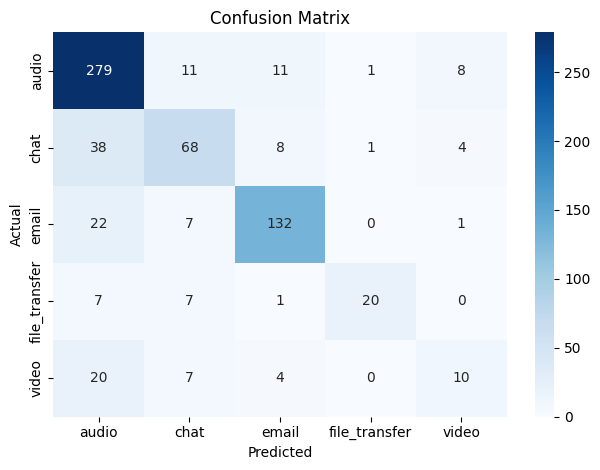

In [19]:
# 학습용 데이터를 불러오고, 불필요한 열을 제거합니다.
csv_candidates = ['output_multiple.csv', 'code/output_multiple.csv', '../code/output_multiple.csv']
csv_target = None
for c in csv_candidates:
    if os.path.exists(c):
        csv_target = c
        break

if csv_target is None:
    raise FileNotFoundError('output_multiple.csv 파일을 찾을 수 없습니다.')

print(f'데이터셋 로드 성공: {csv_target}')
df = pd.read_csv(csv_target).dropna()
X = df.drop(columns=['flow', 'label'])
y = df['label']
print(f'데이터셋 준비 완료: shape={df.shape}')


## 🔥 8. 딥러닝 모델 (PyTorch 기반 MLP) 학습 및 평가

Epoch 1/200 - Loss: 36.4041
Epoch 2/200 - Loss: 32.5622
Epoch 3/200 - Loss: 30.8556
Epoch 4/200 - Loss: 30.5854
Epoch 5/200 - Loss: 29.9182
Epoch 6/200 - Loss: 29.8400
Epoch 7/200 - Loss: 29.8430
Epoch 8/200 - Loss: 29.5928
Epoch 9/200 - Loss: 29.4251
Epoch 10/200 - Loss: 29.2506
Epoch 11/200 - Loss: 29.2987
Epoch 12/200 - Loss: 29.3804
Epoch 13/200 - Loss: 29.0077
Epoch 14/200 - Loss: 28.8769
Epoch 15/200 - Loss: 28.7893
Epoch 16/200 - Loss: 28.8084
Epoch 17/200 - Loss: 29.1430
Epoch 18/200 - Loss: 28.6648
Epoch 19/200 - Loss: 28.8147
Epoch 20/200 - Loss: 28.7151
Epoch 21/200 - Loss: 28.4090
Epoch 22/200 - Loss: 28.5719
Epoch 23/200 - Loss: 28.6493
Epoch 24/200 - Loss: 28.2285
Epoch 25/200 - Loss: 28.3076
Epoch 26/200 - Loss: 28.0711
Epoch 27/200 - Loss: 28.2640
Epoch 28/200 - Loss: 28.0205
Epoch 29/200 - Loss: 27.8490
Epoch 30/200 - Loss: 27.8305
Epoch 31/200 - Loss: 27.7870
Epoch 32/200 - Loss: 27.8502
Epoch 33/200 - Loss: 27.6317
Epoch 34/200 - Loss: 27.7244
Epoch 35/200 - Loss: 27

c:\Users\JIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\JIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\JIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

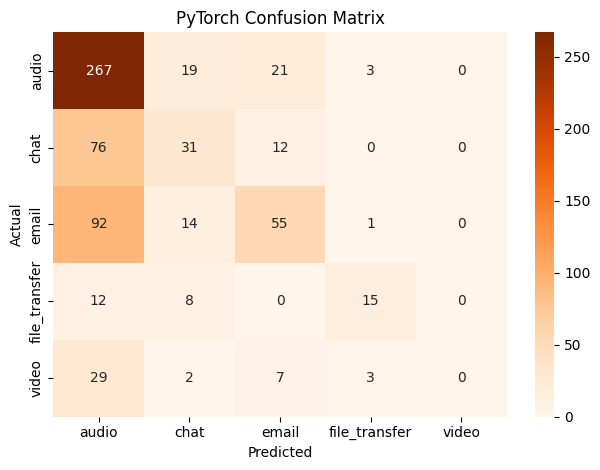

In [20]:
# 학습용 데이터를 불러오고, 불필요한 열을 제거합니다.
csv_candidates = ['output_multiple.csv', 'code/output_multiple.csv', '../code/output_multiple.csv']
csv_target = None
for c in csv_candidates:
    if os.path.exists(c):
        csv_target = c
        break

if csv_target is None:
    raise FileNotFoundError('output_multiple.csv 파일을 찾을 수 없습니다.')

print(f'데이터셋 로드 성공: {csv_target}')
df = pd.read_csv(csv_target).dropna()
X = df.drop(columns=['flow', 'label'])
y = df['label']
print(f'데이터셋 준비 완료: shape={df.shape}')


## 🌲 9. 랜덤포레스트 피처 중요도 분석

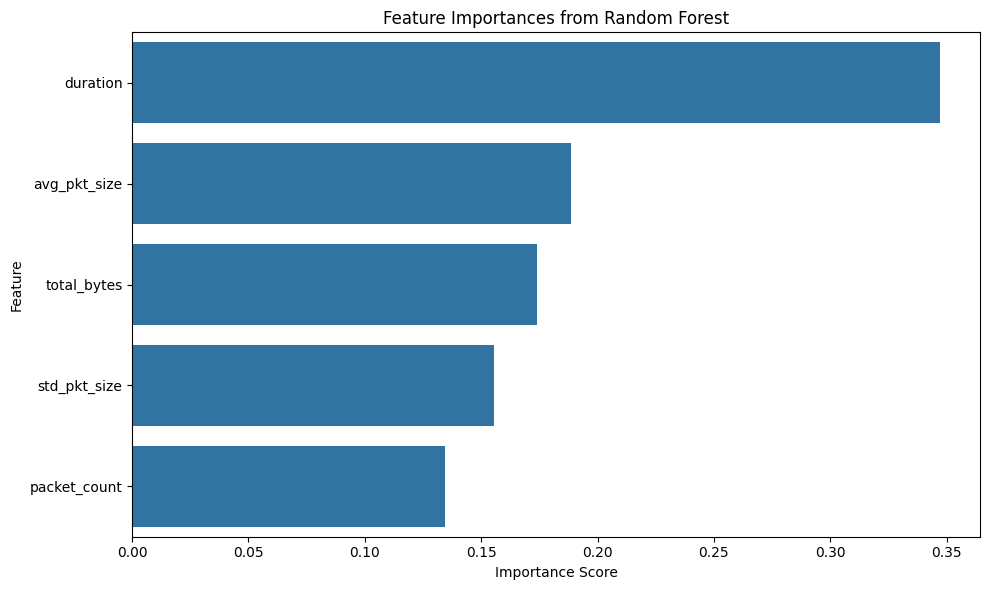

In [21]:
# 학습된 랜덤포레스트 모델을 통해 각 피처의 중요도를 시각화합니다.

# 피처 이름 목록
feature_names = X.columns

# 중요도 추출
importances = clf.feature_importances_

# 중요도를 기준으로 정렬
indices = importances.argsort()[::-1]

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


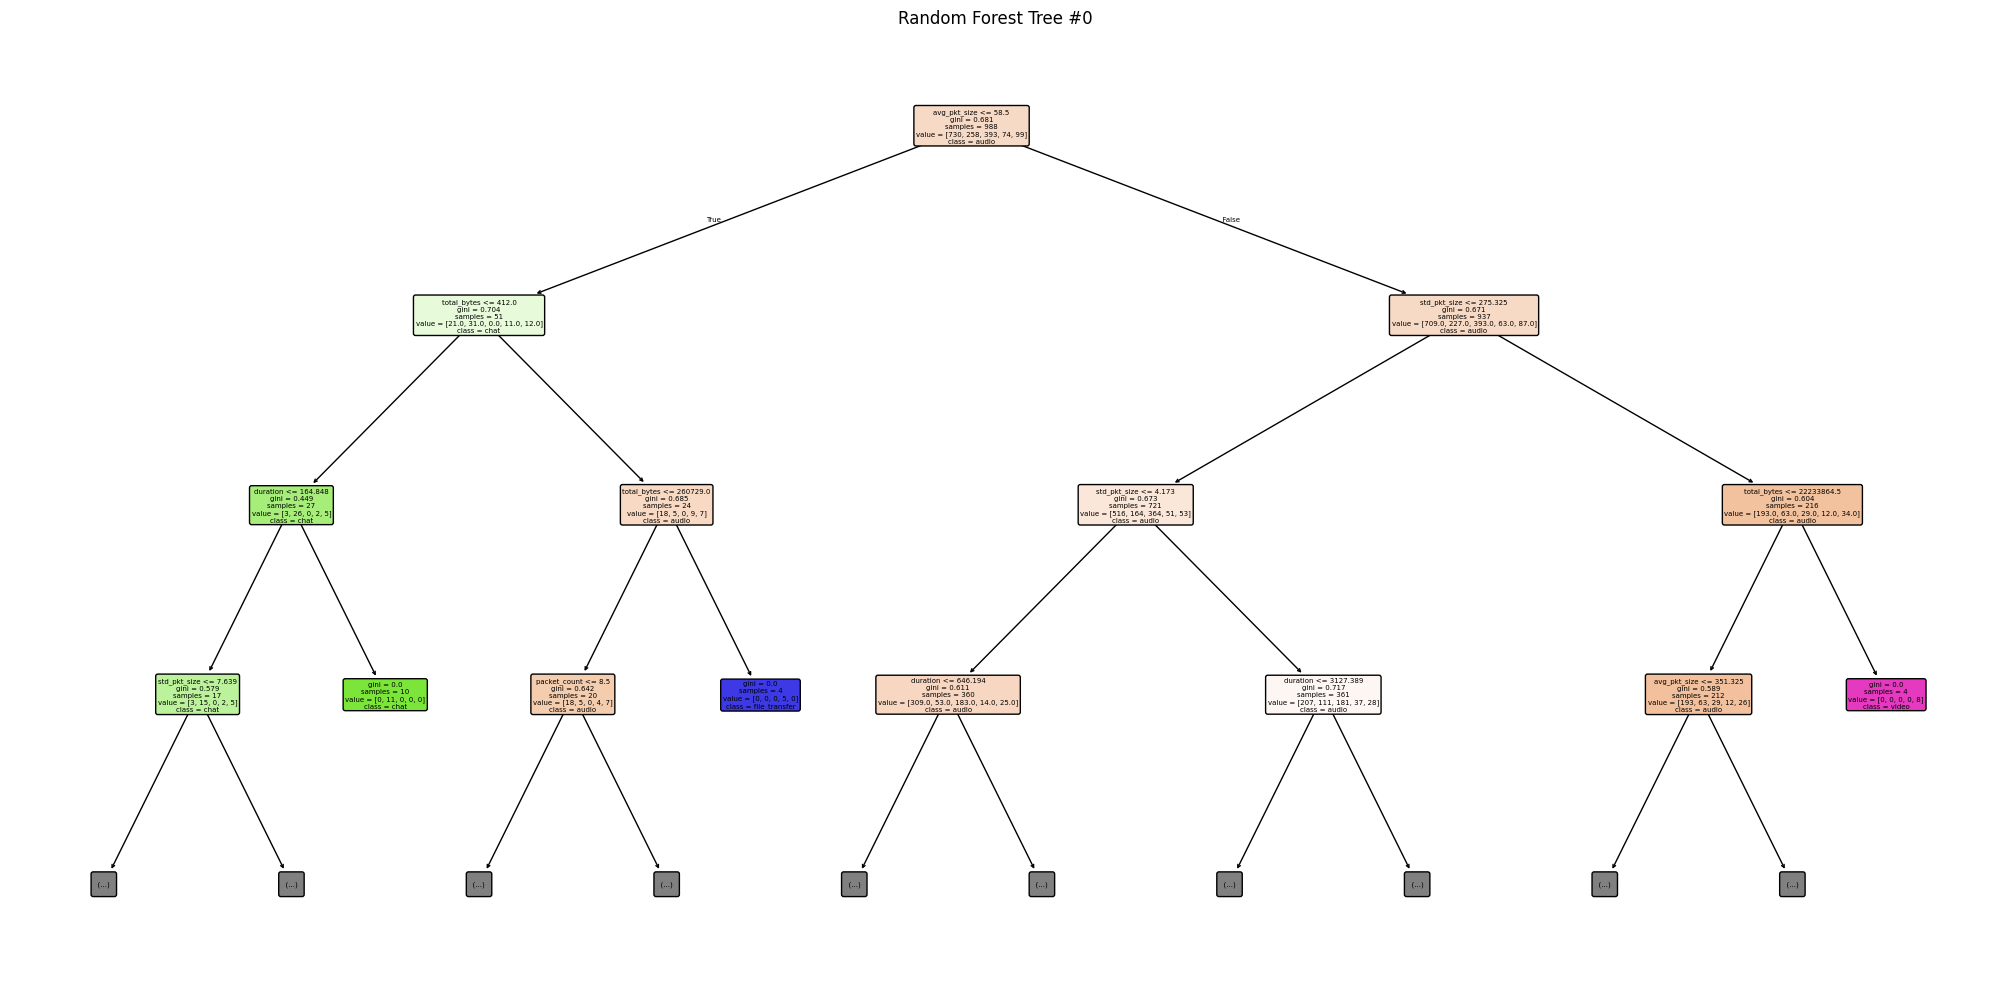

In [22]:
# 랜덤포레스트 내부의 일부 트리를 시각화합니다.
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 몇 개의 트리를 시각화할지 설정
n_trees_to_plot = 1

plt.figure(figsize=(20, 10))
for i in range(n_trees_to_plot):
    plt.clf()
    estimator = clf.estimators_[i]
    plot_tree(estimator,
              feature_names=X.columns,
              class_names=le.classes_,
              filled=True,
              rounded=True,
              max_depth=3)  # 깊이를 제한하여 보기 좋게
    plt.title(f"Random Forest Tree #{i}")
    plt.tight_layout()
    plt.show()